In [50]:
import pandas as pd
import numpy as np
from scipy import stats

from scipy.cluster.hierarchy import linkage, fcluster
# from scipy.conftest import xp_available_backends
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt

import importlib

import utility_functions as uf

In [6]:
importlib.reload(uf)

<module 'utility_functions' from '/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py'>

In [27]:
def get_ks_pval_dist(df):
    country_list = df.index.to_list()
    dist = np.full((len(country_list), len(country_list)), np.nan, dtype=float)

    for i, country1 in enumerate(country_list):
        for j, country2 in enumerate(country_list):
            if i == j:
                dist[i, j] = 0
            if i < j:
                stat, p_val = stats.ks_2samp(df.loc[country1].fillna(0), df.loc[country2].fillna(0), method="exact")
                # print(stat, p_val)
                dist[i, j] = dist[j, i] = p_val
    return pd.DataFrame(dist, index=country_list, columns=country_list)

In [69]:
year = 2022
mode = "individual"

cap = 0.05
n_cap = 1000

df_cs = pd.read_csv(uf.PATH+f"df_country_subfield/{mode}_{year}.csv", index_col=0)

country_idx = df_cs.sum(axis=1).to_frame("total").query("total > @n_cap").index
df_cs = df_cs.loc[country_idx]

n_articles = df_cs.sum(axis=1)

df_prob = df_cs.div(df_cs.sum(axis=1), axis=0)

df_dist = get_ks_pval_dist(df_prob)

np.fill_diagonal(df_dist.values, np.nan)

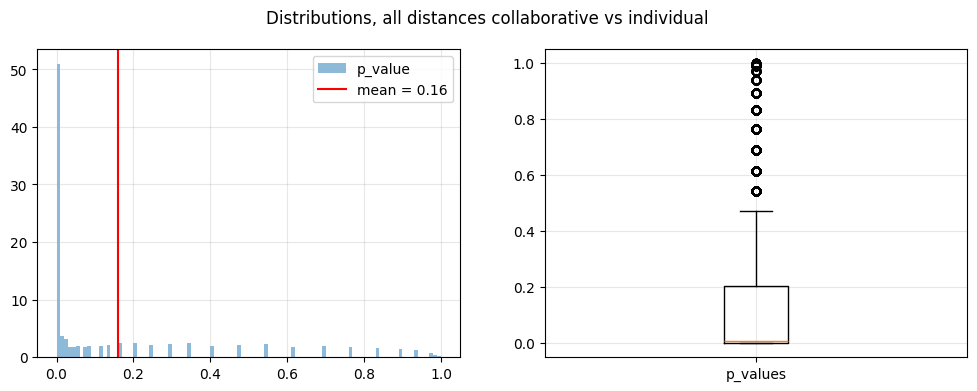

In [70]:
fig, (ax1, ax2) =plt.subplots(ncols=2, nrows=1, figsize=(12, 4))

data1 = df_dist.values.flatten()
data1 = data1[~np.isnan(data1)]


ax1.hist(data1, bins=100, alpha=0.5, label="p_value", density=True)
ax1.axvline(data1.mean(), color="red", label=f"mean = {round(data1.mean(), 2)}")
ax1.legend()
ax1.grid(alpha=0.3)
# plt.show()

plt.subplot(1, 2, 2)

ax2.boxplot([data1], tick_labels=["p_value"])
ax2.set_xticks([1], ["p_values"])
ax2.grid(alpha=0.3)

plt.suptitle("Distributions, all distances collaborative vs individual")
plt.show()

In [71]:
alpha = 0.05

y_labels = df_cs.sum(axis=1).sort_values(ascending=False).index.to_list()
# y_labels = df_dist.index.to_list()
uf.plotly_heatmap(
    (df_dist.loc[y_labels, y_labels] > alpha).astype(int),
    x_labels=y_labels,
    y_labels=y_labels,
    # z_min=0, z_max=1,
    colorscale="non-symmetrical",
    x_type="country",
    y_type="country",
    title=f"KS p_values between countries (1 == cannot reject they are the same), {mode}, {year}",
)

In [72]:
D = df_dist.fillna(0).values

In [73]:
clustering_algorithms = []

In [74]:
condensed_D = squareform(D)

method = "average"
param = "distance"
param_value_list = [0.15, 0.2, 0.3, 0.4, 0.5]

Z = linkage(condensed_D, method=method)

for param_value in param_value_list:
    try: 
        np.random.seed(0)
        labels = fcluster(Z, t=param_value, criterion=param)

        # print("Clusters: ")
        # print(pd.Series(labels).value_counts())
        # print()

        # print("Silhouette Score: ", silhouette_score(D, labels, metric="precomputed"))
        # print("Dunn Index: ", uf.dunn_index(df_dist, labels))

        clustering_algorithms.append({
            "name": "linkage",
            "note": "Hierarchical, {}".format(method),
            "param": param,
            "param_value": param_value,
            "silhouette_score": silhouette_score(D, labels, metric="precomputed"),
            "dunn_index": uf.dunn_index(df_dist, labels),
            "n_clusters": len(set(labels)),
            "max_cluster": max(pd.Series(labels).value_counts()),
            "max_cluster_percent": max(pd.Series(labels).value_counts()) / len(labels),
            "min_cluster": min(pd.Series(labels).value_counts()),
            "min_cluster_percent": min(pd.Series(labels).value_counts()) / len(labels),
        })
    except Exception as e:
        print(e)

Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)
Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)


In [75]:
pd.json_normalize(clustering_algorithms)

,name,note,param,param_value,silhouette_score,dunn_index,n_clusters,max_cluster,max_cluster_percent,min_cluster,min_cluster_percent
0,linkage,"Hierarchical, average",distance,0.15,-0.398569,5.626286e-20,18,72,0.727273,1,0.010101
1,linkage,"Hierarchical, average",distance,0.20,-0.463831,1.000399e+00,12,87,0.878788,1,0.010101
2,linkage,"Hierarchical, average",distance,0.30,-0.194672,1.000399e+00,3,97,0.979798,1,0.010101


In [79]:
import kmedoids

D = df_dist.fillna(0).values

param_value = 2

np.random.seed(0)
c = kmedoids.fasterpam(D, param_value)
# print("Loss is:", c.loss)

labels = c.labels
medoids = df_dist.index[c.medoids].to_list()

print("Clusters: ")
print(pd.Series(labels).value_counts())
print()

print("Silhouette Score: ", silhouette_score(D, labels, metric="precomputed"))
print("Dunn Index: ", uf.dunn_index(df_dist, labels))

Clusters: 
0    60
1    39
Name: count, dtype: int64

Silhouette Score:  -0.6133583429456825
Dunn Index:  5.626286195995624e-20


In [80]:
df_map, df_prob_clusters, df_dist_clusters, df_prob_medoids = uf.get_cluster_data(labels, medoids, df_dist, df_cs)

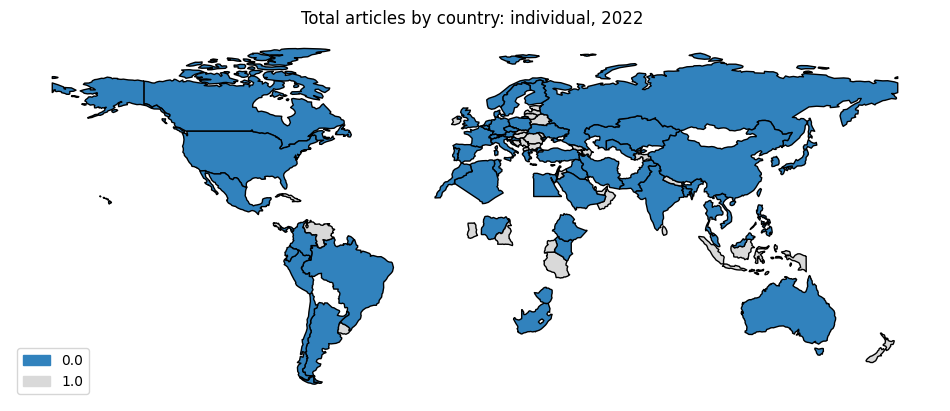

In [81]:
_, _ = uf.plot_map_discrete(df_map, "cluster", country_column="country3", title=f"Total articles by country: {mode}, {year}")